In [ ]:
# 7-6-2026

In [65]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr
from xgboost import XGBRegressor

In [66]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [67]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)

In [68]:
# keep only active domains in descriptors
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

In [69]:
print(transfer_matrix.shape) # should be 34, 34
print(descriptors_active.shape) # should be 34, 33

(34, 34)
(34, 33)


In [70]:
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [71]:
# fit scaler on train descriptors only, transform all 34 active domains
scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

StandardScaler()

In [72]:
desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [73]:
# generate ordered pairs
def make_pairs(id_list, matrix):
    pairs = []
    for i in id_list:
        for j in id_list:
            t_ij = matrix.loc[i, j]
            pairs.append((i, j, t_ij))
    return pairs

train_pairs = make_pairs(train_ids, transfer_matrix)

In [74]:
# test pairs are any pair where at least one domain is holdout
test_pairs = []
for i in active_ids:
    for j in active_ids:
        if i in holdout_ids or j in holdout_ids:
            test_pairs.append((i, j, transfer_matrix.loc[i, j]))

print(f"train pairs: {len(train_pairs)}")
print(f"test pairs: {len(test_pairs)}")
# good :)

train pairs: 900
test pairs: 256


In [75]:
# build flat feature arrays for xgboost, same concat(desc_i, desc_j, diff) as no encoder model
def make_xy(pairs, desc_scaled):
    X = []
    y = []
    for i, j, t_ij in pairs:
        desc_i = desc_scaled.loc[i].values
        desc_j = desc_scaled.loc[j].values
        diff = desc_i - desc_j
        row = np.concatenate([desc_i, desc_j, diff])
        X.append(row)
        y.append(t_ij)
    return np.array(X), np.array(y)

X_train, y_train = make_xy(train_pairs, desc_scaled)
X_test, y_test = make_xy(test_pairs, desc_scaled)

print(X_train.shape) # should be 900x99
print(X_test.shape) # 256,99

(900, 99)
(256, 99)


In [98]:
model = XGBRegressor(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.06,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=5,
    eval_metric="rmse" # doesnt suport mse, will square for plotting
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=10
)

[0]	validation_0-rmse:0.09217	validation_1-rmse:0.10490


[10]	validation_0-rmse:0.07129	validation_1-rmse:0.09402
[20]	validation_0-rmse:0.06004	validation_1-rmse:0.09085
[30]	validation_0-rmse:0.05235	validation_1-rmse:0.08911
[40]	validation_0-rmse:0.04714	validation_1-rmse:0.08779
[50]	validation_0-rmse:0.04321	validation_1-rmse:0.08656
[60]	validation_0-rmse:0.03994	validation_1-rmse:0.08617
[70]	validation_0-rmse:0.03786	validation_1-rmse:0.08585
[80]	validation_0-rmse:0.03583	validation_1-rmse:0.08546
[90]	validation_0-rmse:0.03433	validation_1-rmse:0.08519
[100]	validation_0-rmse:0.03287	validation_1-rmse:0.08532
[110]	validation_0-rmse:0.03187	validation_1-rmse:0.08546
[120]	validation_0-rmse:0.03059	validation_1-rmse:0.08550
[130]	validation_0-rmse:0.02934	validation_1-rmse:0.08557
[140]	validation_0-rmse:0.02814	validation_1-rmse:0.08571
[150]	validation_0-rmse:0.02711	validation_1-rmse:0.08582
[160]	validation_0-rmse:0.02609	validation_1-rmse:0.08609
[170]	validation_0-rmse:0.02520	validation_1-rmse:0.08647
[180]	validation_0-rmse

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


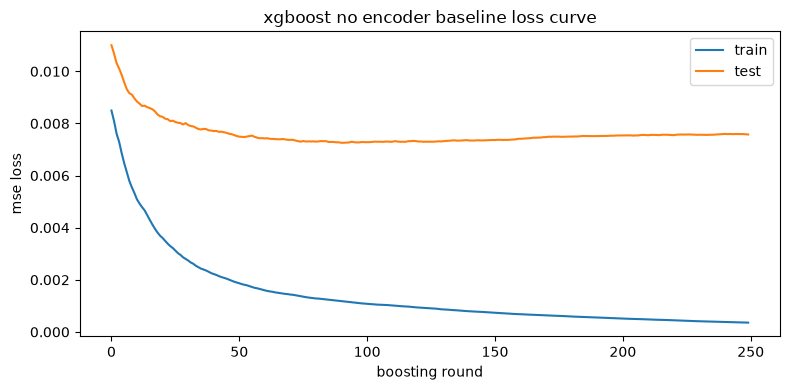

In [99]:
results = model.evals_result()
train_rmse = results["validation_0"]["rmse"]
test_rmse = results["validation_1"]["rmse"]

train_mse = [r ** 2 for r in train_rmse]
test_mse = [r ** 2 for r in test_rmse]

plt.figure(figsize=(8, 4))
plt.plot(train_mse, label="train")
plt.plot(test_mse, label="test")
plt.xlabel("boosting round")
plt.ylabel("mse loss")
plt.title("xgboost no encoder baseline loss curve")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
# get final preds on train and test to compute mae and mse
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_mae_final = np.abs(train_preds - y_train).mean()
train_mse_final = ((train_preds - y_train) ** 2).mean()
test_mae_final = np.abs(test_preds - y_test).mean()
test_mse_final = ((test_preds - y_test) ** 2).mean()

In [101]:
print(f"train mse: {train_mse_final:.4f}, test mse: {test_mse_final:.4f}")
print(f"train mae: {train_mae_final:.4f}, test mae: {test_mae_final:.4f}")

train mse: 0.0004, test mse: 0.0076
train mae: 0.0149, test mae: 0.0700


In [102]:
# generate all 34x34 pairs
all_pairs = [(i, j) for i in active_ids for j in active_ids]
all_targets = [transfer_matrix.loc[i, j] for i, j in all_pairs]

all_X = []
for i, j in all_pairs:
    desc_i = desc_scaled.loc[i].values
    desc_j = desc_scaled.loc[j].values
    diff = desc_i - desc_j
    row = np.concatenate([desc_i, desc_j, diff])
    all_X.append(row)

all_X = np.array(all_X)
all_preds = model.predict(all_X)

In [103]:
pred_matrix = pd.DataFrame(
    all_preds.reshape(34, 34),
    index=active_ids,
    columns=active_ids
)
pred_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.422916,0.267405,0.118854,0.072110,0.209210,0.089300,0.140259,0.197033,0.172163,0.043448,...,0.204125,0.197841,0.141550,0.271657,0.159073,-0.003677,0.119032,0.145833,0.136358,0.088174
1,0.132224,0.372936,0.018774,0.026538,0.159494,0.056353,0.050307,0.122099,0.083579,0.035342,...,0.148052,0.047564,0.033311,0.184790,0.051414,0.058260,0.033156,0.085162,0.035086,0.071975
2,0.197729,0.214376,0.411347,0.042563,0.206085,0.117786,0.164529,0.223776,0.162216,0.056164,...,0.186268,0.194283,0.120743,0.258035,0.149518,0.043629,0.138142,0.109870,0.094973,0.097347
4,0.207481,0.216066,0.128431,0.401729,0.209708,0.171541,0.136227,0.191305,0.164637,0.051143,...,0.180342,0.241195,0.166199,0.280389,0.200734,0.002234,0.119535,0.222951,0.178340,0.100695
5,0.217136,0.229034,0.101726,0.086549,0.453289,0.124287,0.147896,0.217123,0.229876,0.094095,...,0.198625,0.207909,0.126130,0.293456,0.179496,0.001818,0.135826,0.129731,0.143467,0.098206


In [104]:
pred_matrix.to_csv("xgboost_transfer_matrix.csv")

In [105]:
xgb_matrix = pd.read_csv("xgboost_transfer_matrix.csv")
xgb_matrix.set_index("Unnamed: 0", inplace=True)
xgb_matrix.index.name = None
xgb_matrix.index = xgb_matrix.index.astype(int)
xgb_matrix.columns = xgb_matrix.columns.astype(int)
xgb_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.422916,0.267405,0.118854,0.072110,0.209210,0.089300,0.140259,0.197033,0.172163,0.043448,...,0.204125,0.197841,0.141550,0.271657,0.159073,-0.003677,0.119032,0.145833,0.136358,0.088174
1,0.132224,0.372937,0.018774,0.026538,0.159494,0.056353,0.050307,0.122099,0.083579,0.035342,...,0.148052,0.047564,0.033311,0.184790,0.051414,0.058260,0.033156,0.085162,0.035086,0.071975
2,0.197729,0.214376,0.411347,0.042563,0.206085,0.117786,0.164529,0.223776,0.162216,0.056164,...,0.186268,0.194283,0.120743,0.258035,0.149518,0.043629,0.138142,0.109870,0.094973,0.097347
4,0.207481,0.216066,0.128431,0.401729,0.209708,0.171541,0.136227,0.191305,0.164637,0.051143,...,0.180342,0.241195,0.166199,0.280389,0.200734,0.002234,0.119535,0.222951,0.178340,0.100695
5,0.217136,0.229034,0.101726,0.086549,0.453289,0.124287,0.147896,0.217123,0.229876,0.094095,...,0.198625,0.207909,0.126130,0.293456,0.179496,0.001818,0.135826,0.129731,0.143467,0.098206


In [106]:
true_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
true_matrix.set_index("Unnamed: 0", inplace=True)
true_matrix.index.name = None
true_matrix.index = true_matrix.index.astype(int)
true_matrix.columns = true_matrix.columns.astype(int)
true_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [107]:
print(kendalltau(true_matrix.values.flatten(), xgb_matrix.values.flatten()))

SignificanceResult(statistic=np.float64(0.719813058913405), pvalue=np.float64(3.8133747484114056e-294))


In [ ]:
# next will be to show that the encoder learned something cool in the embedding space.
# next step is to obtain encoder embeddings for each domain
# later will do pca (or tsne/umap for better clustering) on embeddings

# even later, generate a distance matrix between embeddings, negate, see kendall w ground truth
#   and with raw distance matrix (if embedding structure perserved descriptor structure)